# Texas Crude Oil Production Forecasting
### Applied Forecasting Methods
Dataset: Texas Field Production of Crude Oil (Thousand Barrels), Jan 1981 – Jan 2026

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded.')

Libraries loaded.


## 1. Data Loading & Preprocessing

In [ ]:
df = pd.read_csv('Texas_dataset.csv', skiprows=3, header=None, names=['Date','Production'])
df = df.dropna(subset=['Date'])
df = df[df['Date'].str.strip() != '']
df['Date'] = pd.to_datetime(df['Date'], format='%b-%Y')
df['Production'] = pd.to_numeric(df['Production'], errors='coerce')
df = df.dropna().sort_values('Date').reset_index(drop=True)
df.rename(columns={'Production':'Monthly oil production'}, inplace=True)
print(f'Shape: {df.shape}')
print(f'Date range: {df.Date.min()} to {df.Date.max()}')
df.head()

Shape: (541, 2)
Date range: 1981-01-01 00:00:00 to 2026-01-01 00:00:00


,Date,Monthly oil production
0,1981-01-01,80609.0
1,1981-02-01,72591.0
2,1981-03-01,80734.0
3,1981-04-01,77344.0
4,1981-05-01,79890.0


In [ ]:
print('=== Dataset Summary ===')
print(f'Total observations : {len(df)}')
print(f'Min production     : {df["Monthly oil production"].min():,.0f} thousand barrels')
print(f'Max production     : {df["Monthly oil production"].max():,.0f} thousand barrels')
print(f'Mean production    : {df["Monthly oil production"].mean():,.0f} thousand barrels')
print(f'Std deviation      : {df["Monthly oil production"].std():,.0f} thousand barrels')
print(f'Missing values     : {df["Monthly oil production"].isna().sum()}')

=== Dataset Summary ===
Total observations : 541
Min production     : 30,189 thousand barrels
Max production     : 181,046 thousand barrels
Mean production    : 74,023 thousand barrels
Std deviation      : 44,047 thousand barrels
Missing values     : 0


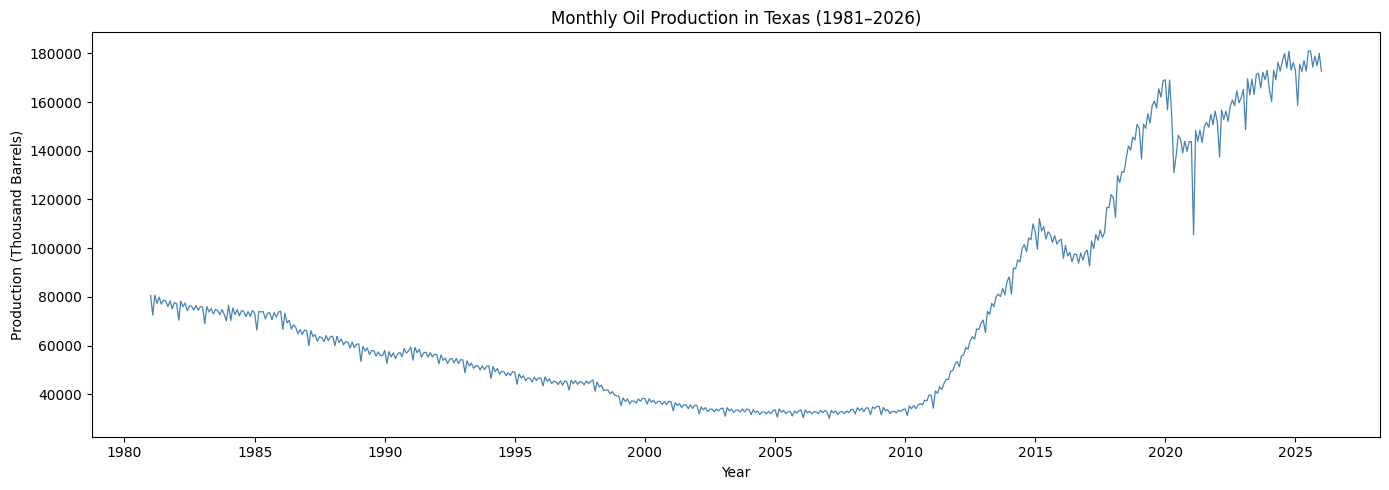

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(df['Date'], df['Monthly oil production'], color='steelblue', linewidth=0.9)
plt.title('Monthly Oil Production in Texas (1981–2026)')
plt.xlabel('Year'); plt.ylabel('Production (Thousand Barrels)')
plt.tight_layout(); plt.show()

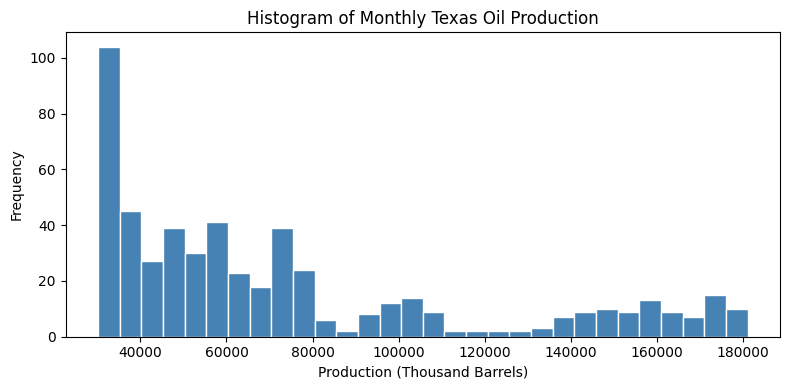

In [ ]:
plt.figure(figsize=(8,4))
plt.hist(df['Monthly oil production'], bins=30, color='steelblue', edgecolor='white')
plt.title('Histogram of Monthly Texas Oil Production')
plt.xlabel('Production (Thousand Barrels)'); plt.ylabel('Frequency')
plt.tight_layout(); plt.show()

## 2. Transformations & Train-Validation-Test Split
*Crucial: We create First and Second-Order differences, and split the data before EDA to prevent future-peeking leakage.*

In [ ]:
# Create First and Second Differences
df['First_Diff'] = df['Monthly oil production'].diff()
df['Log_Production'] = np.log(df['Monthly oil production'])
df['Log_First_Diff'] = df['Log_Production'].diff()

df['Second_Diff'] = df['First_Diff'].diff()
df['Log_Second_Diff'] = df['Log_First_Diff'].diff()

# Split 70/20/10
n = len(df)
train_idx = int(0.70 * n)
val_idx = int(0.90 * n)

train = df.iloc[:train_idx].copy()
val   = df.iloc[train_idx:val_idx].copy()
test  = df.iloc[val_idx:].copy()

train_val = df.iloc[:val_idx].copy()

print(f'Train : {len(train)} obs ({train.Date.min().date()} → {train.Date.max().date()})')
print(f'Val   : {len(val)} obs ({val.Date.min().date()} → {val.Date.max().date()})')
print(f'Test  : {len(test)} obs ({test.Date.min().date()} → {test.Date.max().date()})')

test_start = len(train_val)
test_end = test_start + len(test)
test_actuals = test['Monthly oil production'].values

Train : 378 obs (1981-01-01 → 2012-06-01)
Val   : 108 obs (2012-07-01 → 2021-06-01)
Test  : 55 obs (2021-07-01 → 2026-01-01)


## 3. Leakage-Free EDA & Stationarity (Train Set Only)

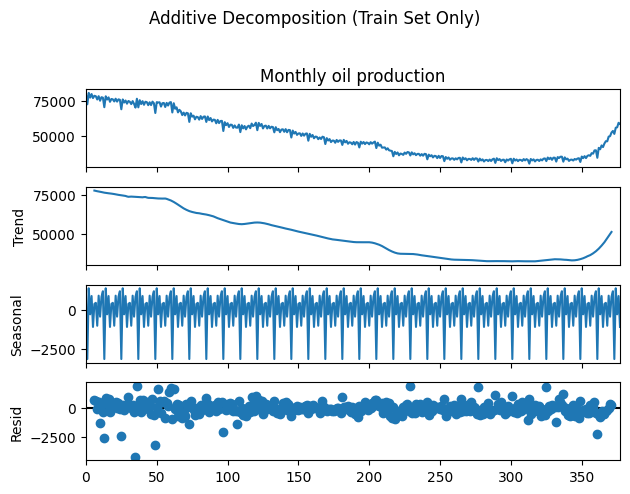

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

result_add = seasonal_decompose(train['Monthly oil production'], model='additive', period=12)
result_add.plot()
plt.suptitle('Additive Decomposition (Train Set Only)', y=1.02)
plt.tight_layout(); plt.show()

In [ ]:
print('=== ADF Tests (Train Set Only) ===')
series_dict = {
    'Normal Data': train['Monthly oil production'].dropna(),
    'First Difference': train['First_Diff'].dropna(),
    'Log First Diff': train['Log_First_Diff'].dropna(),
    'Second Difference': train['Second_Diff'].dropna(),
    'Log Second Diff': train['Log_Second_Diff'].dropna()
}

for name, series in series_dict.items():
    result = adfuller(series)
    print(f"{name:25} | p-value: {result[1]:.6f} | {'Stationary' if result[1]<0.05 else 'Non-Stationary'}")

=== ADF Tests (Train Set Only) ===
Normal Data               | p-value: 0.768652 | Non-Stationary
First Difference          | p-value: 0.866712 | Non-Stationary
Log First Diff            | p-value: 0.749297 | Non-Stationary
Second Difference         | p-value: 0.000000 | Stationary
Log Second Diff           | p-value: 0.000000 | Stationary


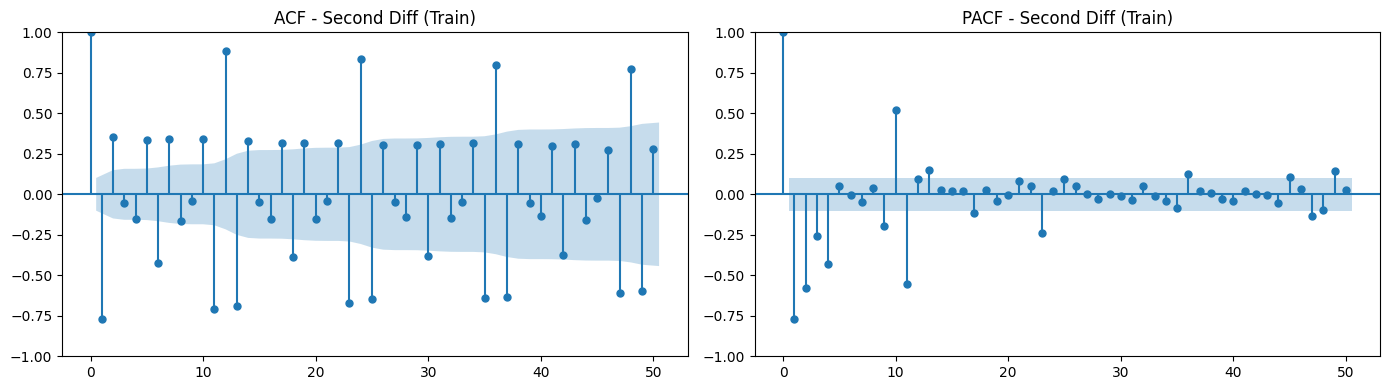

In [ ]:
# Plot ACF/PACF for Second Difference
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train['Second_Diff'].dropna(), lags=50, ax=axes[0])
axes[0].set_title('ACF - Second Diff (Train)')
plot_pacf(train['Second_Diff'].dropna(), lags=50, ax=axes[1])
axes[1].set_title('PACF - Second Diff (Train)')
plt.tight_layout(); plt.show()

## 4. Naive Baseline Methods & Error Function Setup

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, mean_absolute_error, r2_score

# Helper function to calculate all requested error metrics
def get_error_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, mape, r2

test_naive = test.copy()
test_naive['mean_pred'] = [df['Monthly oil production'].iloc[:val_idx + i].mean() for i in range(len(test))]
test_naive['last_year'] = [df['Monthly oil production'].iloc[val_idx + i - 12 : val_idx + i].mean() for i in range(len(test))]
test_naive['last_val'] = df['Monthly oil production'].shift(1).iloc[val_idx:].values
test_naive['last_seas'] = df['Monthly oil production'].shift(12).iloc[val_idx:].values

# Evaluate Last Year Mean (Best Naive)
rmse_naive, mae_naive, mape_naive, r2_naive = get_error_metrics(test_actuals, test_naive['last_year'])

print("=== Naive Baselines (Evaluated on Test Set) ===")
print(f'Mean MAPE       : {mean_absolute_percentage_error(test_actuals, test_naive["mean_pred"])*100:.2f}%')
print(f'Last Year Mean  : {mape_naive*100:.2f}%  (RMSE: {rmse_naive:,.0f} | MAE: {mae_naive:,.0f} | R2: {r2_naive:.4f})')
print(f'Last Value      : {mean_absolute_percentage_error(test_actuals, test_naive["last_val"])*100:.2f}%')
print(f'Last Season     : {mean_absolute_percentage_error(test_actuals, test_naive["last_seas"])*100:.2f}%')

=== Naive Baselines (Evaluated on Test Set) ===
Mean MAPE       : 58.61%
Last Year Mean  : 3.61%  (RMSE: 6,885 | MAE: 5,900 | R2: 0.5553)
Last Value      : 3.78%
Last Season     : 4.68%


## 5. Statistical Models: AR, MA, ARIMA, SARIMA
*(Tuned on Val Set, Evaluated on Test Set)*

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

Best AR(p=3) selected. AIC: 7115.05 | Val MAPE: 9.73%
Rolling AR Test | RMSE: 7,499 | MAE: 5,869 | MAPE: 3.59% | R2: 0.4724


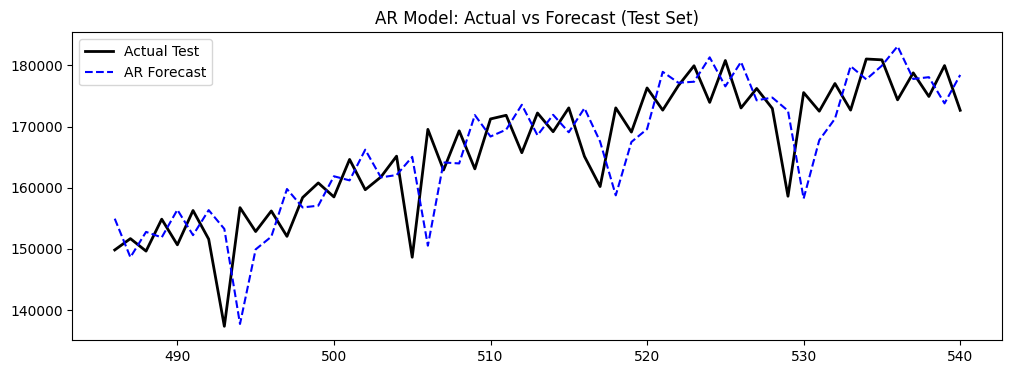

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

\nBest MA(q=11) selected. AIC: 7164.33 | Val MAPE: 9.26%


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

Rolling MA Test | RMSE: 6,627 | MAE: 4,933 | MAPE: 3.02% | R2: 0.5880


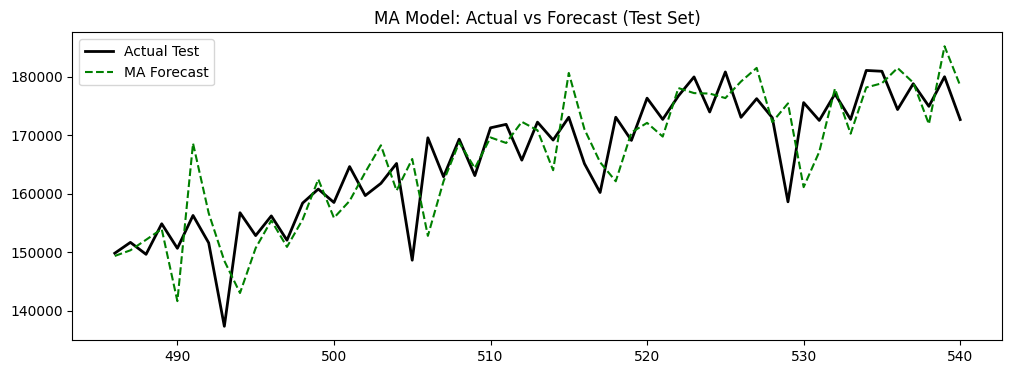

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

\nBest ARIMA(1,2,2) selected. AIC: 7112.56 | Val MAPE: 9.65%
Rolling ARIMA Test | RMSE: 6,761 | MAE: 5,285 | MAPE: 3.24% | R2: 0.5711


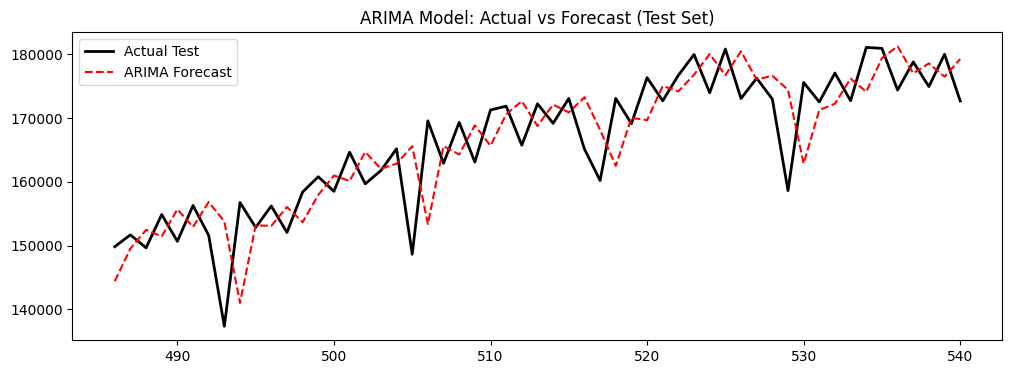

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

\nBest SARIMA selected. AIC: 6245.09 | Val MAPE: 58.00%


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Rolling SARIMA Test | RMSE: 4,058 | MAE: 2,734 | MAPE: 1.68% | R2: 0.8455


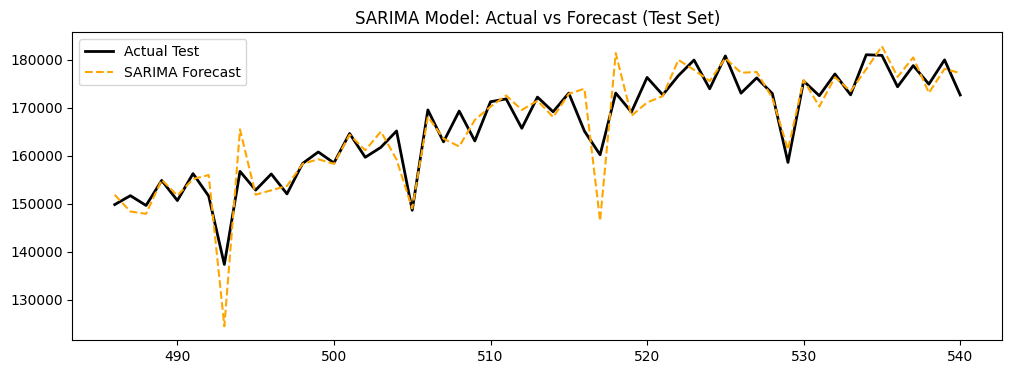

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# --- AR MODEL ---
min_mape_ar, best_p, ar_aic = 1e9, -1, np.nan
for p in range(1, 13):
    m = ARIMA(train['Monthly oil production'], order=(p,2,0)).fit() # d=2 for second diff
    pred = m.predict(start=len(train), end=len(train)+len(val)-1)
    mape = mean_absolute_percentage_error(val['Monthly oil production'], pred)
    if mape < min_mape_ar:
        min_mape_ar = mape; best_p = p; ar_aic = m.aic

print(f'Best AR(p={best_p}) selected. AIC: {ar_aic:.2f} | Val MAPE: {min_mape_ar*100:.2f}%')

history = train_val['Monthly oil production'].tolist()
ar_rolling_preds = []
for t in range(len(test_actuals)):
    model = ARIMA(history, order=(best_p, 2, 0)).fit()
    ar_rolling_preds.append(model.forecast()[0])
    history.append(test_actuals[t])

rmse_ar, mae_ar, mape_ar, r2_ar = get_error_metrics(test_actuals, ar_rolling_preds)
print(f'Rolling AR Test | RMSE: {rmse_ar:,.0f} | MAE: {mae_ar:,.0f} | MAPE: {mape_ar*100:.2f}% | R2: {r2_ar:.4f}')

# Plot AR
plt.figure(figsize=(12,4))
plt.plot(range(test_start, test_end), test_actuals, label='Actual Test', color='black', linewidth=2)
plt.plot(range(test_start, test_end), ar_rolling_preds, label='AR Forecast', color='blue', linestyle='--')
plt.title('AR Model: Actual vs Forecast (Test Set)')
plt.legend(); plt.show()


# --- MA MODEL ---
min_mape_ma, best_q, ma_aic = 1e9, -1, np.nan
for q in range(1, 13):
    m = ARIMA(train['Monthly oil production'], order=(0,2,q)).fit()
    pred = m.predict(start=len(train), end=len(train)+len(val)-1)
    mape = mean_absolute_percentage_error(val['Monthly oil production'], pred)
    if mape < min_mape_ma:
        min_mape_ma = mape; best_q = q; ma_aic = m.aic

print(f'\\nBest MA(q={best_q}) selected. AIC: {ma_aic:.2f} | Val MAPE: {min_mape_ma*100:.2f}%')

history = train_val['Monthly oil production'].tolist()
ma_rolling_preds = []
for t in range(len(test_actuals)):
    model = ARIMA(history, order=(0, 2, best_q)).fit()
    ma_rolling_preds.append(model.forecast()[0])
    history.append(test_actuals[t])

rmse_ma, mae_ma, mape_ma, r2_ma = get_error_metrics(test_actuals, ma_rolling_preds)
print(f'Rolling MA Test | RMSE: {rmse_ma:,.0f} | MAE: {mae_ma:,.0f} | MAPE: {mape_ma*100:.2f}% | R2: {r2_ma:.4f}')

# Plot MA
plt.figure(figsize=(12,4))
plt.plot(range(test_start, test_end), test_actuals, label='Actual Test', color='black', linewidth=2)
plt.plot(range(test_start, test_end), ma_rolling_preds, label='MA Forecast', color='green', linestyle='--')
plt.title('MA Model: Actual vs Forecast (Test Set)')
plt.legend(); plt.show()


# --- ARIMA MODEL ---
min_mape_arima, best_pa, best_qa, arima_aic = 1e9, 0, 0, np.nan
for p in range(1, 4):
    for q in range(1, 4):
        try:
            m = ARIMA(train['Monthly oil production'], order=(p,2,q)).fit()
            pred = m.predict(start=len(train), end=len(train)+len(val)-1)
            mape = mean_absolute_percentage_error(val['Monthly oil production'], pred)
            if mape < min_mape_arima:
                min_mape_arima = mape; best_pa = p; best_qa = q; arima_aic = m.aic
        except: pass

print(f'\\nBest ARIMA({best_pa},2,{best_qa}) selected. AIC: {arima_aic:.2f} | Val MAPE: {min_mape_arima*100:.2f}%')

history = train_val['Monthly oil production'].tolist()
arima_rolling_preds = []
for t in range(len(test_actuals)):
    model = ARIMA(history, order=(best_pa, 2, best_qa)).fit()
    arima_rolling_preds.append(model.forecast()[0])
    history.append(test_actuals[t])

rmse_arima, mae_arima, mape_arima, r2_arima = get_error_metrics(test_actuals, arima_rolling_preds)
print(f'Rolling ARIMA Test | RMSE: {rmse_arima:,.0f} | MAE: {mae_arima:,.0f} | MAPE: {mape_arima*100:.2f}% | R2: {r2_arima:.4f}')

# Plot ARIMA
plt.figure(figsize=(12,4))
plt.plot(range(test_start, test_end), test_actuals, label='Actual Test', color='black', linewidth=2)
plt.plot(range(test_start, test_end), arima_rolling_preds, label='ARIMA Forecast', color='red', linestyle='--')
plt.title('ARIMA Model: Actual vs Forecast (Test Set)')
plt.legend(); plt.show()


# --- SARIMA MODEL ---
min_s, bo, bs, sarima_aic = 1e9, (1,2,1), (1,1,1,12), np.nan
for p in range(1,3):
    for q in range(1,3):
        for P in range(1,3):
            for Q in range(1,3):
                try:
                    m = ARIMA(train['Monthly oil production'], order=(p,2,q), seasonal_order=(P,1,Q,12)).fit()
                    pred = m.predict(start=len(train), end=len(train)+len(val)-1)
                    mape = mean_absolute_percentage_error(val['Monthly oil production'], pred)
                    if mape < min_s:
                        min_s = mape; bo = (p,2,q); bs = (P,1,Q,12); sarima_aic = m.aic
                except: pass

print(f'\\nBest SARIMA selected. AIC: {sarima_aic:.2f} | Val MAPE: {min_s*100:.2f}%')

history = train_val['Monthly oil production'].tolist()
sarima_rolling_preds = []
for t in range(len(test_actuals)):
    model = ARIMA(history, order=bo, seasonal_order=bs).fit()
    sarima_rolling_preds.append(model.forecast()[0])
    history.append(test_actuals[t])

rmse_sarima, mae_sarima, mape_sarima, r2_sarima = get_error_metrics(test_actuals, sarima_rolling_preds)
print(f'Rolling SARIMA Test | RMSE: {rmse_sarima:,.0f} | MAE: {mae_sarima:,.0f} | MAPE: {mape_sarima*100:.2f}% | R2: {r2_sarima:.4f}')

# Plot SARIMA
plt.figure(figsize=(12,4))
plt.plot(range(test_start, test_end), test_actuals, label='Actual Test', color='black', linewidth=2)
plt.plot(range(test_start, test_end), sarima_rolling_preds, label='SARIMA Forecast', color='orange', linestyle='--')
plt.title('SARIMA Model: Actual vs Forecast (Test Set)')
plt.legend(); plt.show()

## 6. Deep Learning Data Preparation
*Explicitly training on Scaled Second Differenced Data to avoid leakage and stabilize gradients.*

In [15]:
import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras.layers import LSTM, SimpleRNN, GRU, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
!pip install keras-tuner
import keras_tuner as kt

# Extract Second Difference
diff_series = df['Second_Diff'].dropna().values.reshape(-1, 1)

# Split indices must account for the 2 rows dropped by second differencing
train_diff = diff_series[:train_idx-2]
val_diff = diff_series[train_idx-2:val_idx-2]
test_diff = diff_series[val_idx-2:]

# --- SCALE THE DATA TO PREVENT GRADIENT SATURATION ---
scaler = MinMaxScaler(feature_range=(-1, 1))
train_scaled = scaler.fit_transform(train_diff)
val_scaled = scaler.transform(val_diff)
test_scaled = scaler.transform(test_diff)

train_val_scaled = np.concatenate((train_scaled, val_scaled))

def create_sequences(data, ts):
    X, y = [], []
    for i in range(len(data)-ts):
        X.append(data[i:i+ts])
        y.append(data[i+ts])
    return np.array(X), np.array(y).reshape(-1, 1)

print('DL stationary data scaled and ready for Train/Val/Test.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.6 MB/s eta 0:00:00
DL stationary data scaled and ready for Train/Val/Test.


## 7a. GRU Model (Point Forecast)

GRU Selected via Val Set | timesteps=10 | Val MAPE: 3.23%
Rolling GRU Test Set MAPE: 2.55%


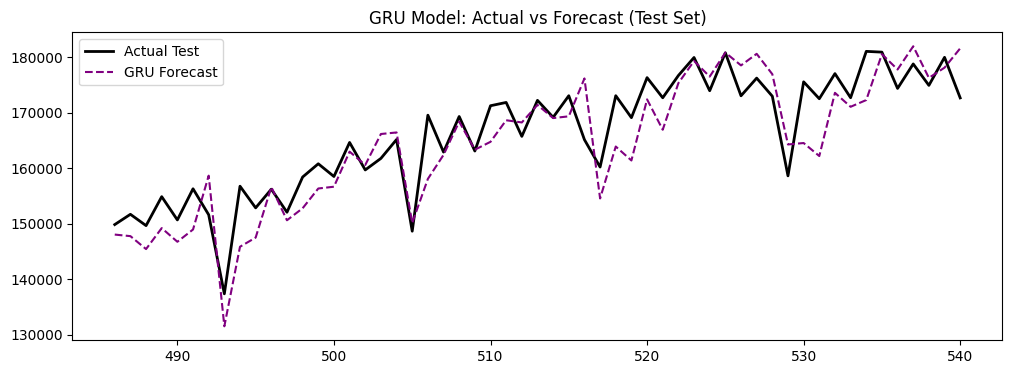

In [24]:
best_GRU = []
for ts in range(10, 16):
    x_tr, y_tr = create_sequences(train_scaled, ts)
    x_va, y_va = create_sequences(val_scaled, ts)

    def build_gru(hp):
        m = Sequential()
        m.add(GRU(hp.Int('units', 16, 64, 16), activation='tanh', input_shape=(ts, 1)))
        m.add(Dense(1))
        m.compile(optimizer='adam', loss='mse')
        return m

    tuner = kt.RandomSearch(build_gru, 'val_loss', 3, directory='GRU_Tune', project_name=f'GRU_2_{ts}', overwrite=True)
    tuner.search(x_tr, y_tr, epochs=10, validation_data=(x_va, y_va), verbose=0)
    best_GRU.append((ts, tuner.get_best_models()[0]))

min_gru_val_mape, gru_model, gru_ts = 1e9, None, None
val_actuals = val['Monthly oil production'].values
val_actuals_prev = df['Monthly oil production'].shift(1).iloc[train_idx:val_idx].values
val_first_diff_prev = df['First_Diff'].shift(1).iloc[train_idx:val_idx].values

es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

for ts, model in best_GRU:
    x_tr, y_tr = create_sequences(train_scaled, ts)
    x_va, y_va = create_sequences(val_scaled, ts)
    model.fit(x_tr, y_tr, epochs=100, validation_data=(x_va, y_va), callbacks=[es], verbose=0)

    inputs_va = np.concatenate((train_scaled[-ts:], val_scaled))
    x_va_roll, _ = create_sequences(inputs_va, ts)

    # Predict Scaled Diff, INVERSE TRANSFORM, then reconstruct original
    pred_va_scaled = model.predict(x_va_roll, verbose=0)
    pred_va_sec_diff = scaler.inverse_transform(pred_va_scaled).flatten()
    pred_va_orig = pred_va_sec_diff + val_first_diff_prev + val_actuals_prev

    mape_va = mean_absolute_percentage_error(val_actuals, pred_va_orig)
    if mape_va < min_gru_val_mape:
        min_gru_val_mape = mape_va; gru_model = model; gru_ts = ts

print(f'GRU Selected via Val Set | timesteps={gru_ts} | Val MAPE: {min_gru_val_mape*100:.2f}%')

# Test Evaluation
test_actuals_prev = df['Monthly oil production'].shift(1).iloc[val_idx:].values
test_first_diff_prev = df['First_Diff'].shift(1).iloc[val_idx:].values

inputs_g = np.concatenate((train_val_scaled[-gru_ts:], test_scaled))
x_te_g, _ = create_sequences(inputs_g, gru_ts)
gru_pred_scaled = gru_model.predict(x_te_g, verbose=0)
gru_pred_sec_diff = scaler.inverse_transform(gru_pred_scaled).flatten()
gru_pred_orig = gru_pred_sec_diff + test_first_diff_prev + test_actuals_prev

min_gru_test = mean_absolute_percentage_error(test_actuals, gru_pred_orig)
print(f'Rolling GRU Test Set MAPE: {min_gru_test*100:.2f}%')

# Plot GRU
plt.figure(figsize=(12,4))
plt.plot(range(test_start, test_end), test_actuals, label='Actual Test', color='black', linewidth=2)
plt.plot(range(test_start, test_end), gru_pred_orig, label='GRU Forecast', color='purple', linestyle='--')
plt.title('GRU Model: Actual vs Forecast (Test Set)')
plt.legend(); plt.show()

## 7b. GRU Probabilistic Model (Conformal Calibration - 5th & 95th Percentiles)

Rolling GRU Probabilistic Forecast | PICP: 87.27% | Mean PI Width: 17,265 bbls


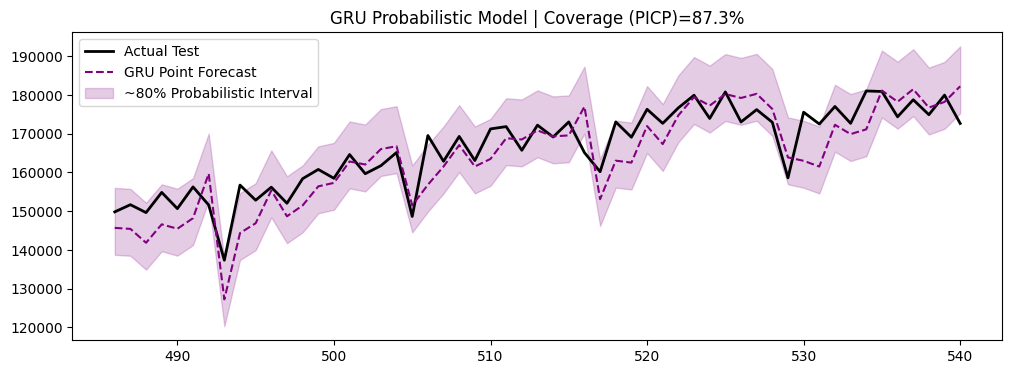

In [25]:
# Probabilistic Forecast Generation (using 5th & 95th validation percentiles)
margin_q10 = np.percentile(best_gru_residuals, 5)
margin_q90 = np.percentile(best_gru_residuals, 95)

gru_q10_orig = gru_point_forecast + margin_q10
gru_q90_orig = gru_point_forecast + margin_q90

gru_picp = float(((test_actuals >= gru_q10_orig) & (test_actuals <= gru_q90_orig)).mean())
gru_mpiw = float((gru_q90_orig - gru_q10_orig).mean())

print(f'Rolling GRU Probabilistic Forecast | PICP: {gru_picp*100:.2f}% | Mean PI Width: {gru_mpiw:,.0f} bbls')

# Plot GRU Probabilistic
plt.figure(figsize=(12,4))
plt.plot(range(test_start, test_end), test_actuals, label='Actual Test', color='black', linewidth=2)
plt.plot(range(test_start, test_end), gru_point_forecast, label='GRU Point Forecast', color='purple', linestyle='--')
plt.fill_between(range(test_start, test_end), gru_q10_orig, gru_q90_orig, color='purple', alpha=0.2, label='~80% Probabilistic Interval')
plt.title(f'GRU Probabilistic Model | Coverage (PICP)={gru_picp*100:.1f}%')
plt.legend(); plt.show()

## 8a. LSTM Model (Point Forecast)

LSTM Selected via Val Set | timesteps=11 | Val MAPE: 3.51%
Rolling LSTM Test Set MAPE: 2.58%


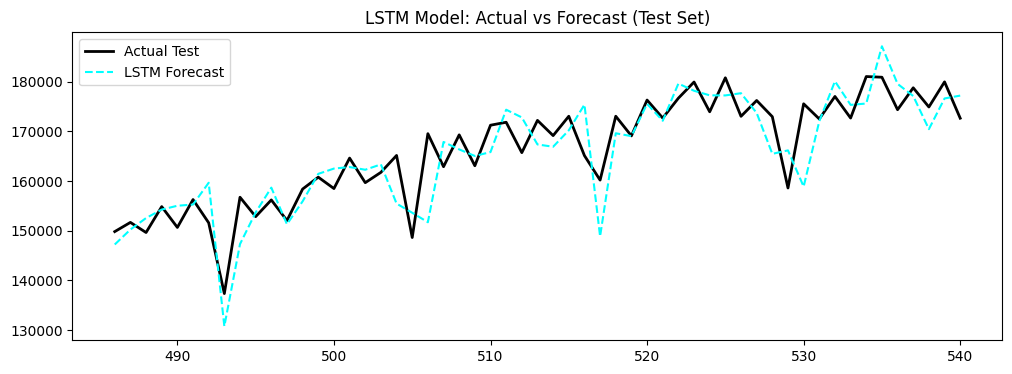

In [26]:
best_LSTM = []
for ts in range(10, 16):
    x_tr, y_tr = create_sequences(train_scaled, ts)
    x_va, y_va = create_sequences(val_scaled, ts)

    def build_lstm(hp):
        m = Sequential()
        m.add(LSTM(hp.Int('units', 16, 64, 16), activation='tanh', input_shape=(ts, 1)))
        m.add(Dense(1))
        m.compile(optimizer='adam', loss='mse')
        return m

    tuner = kt.RandomSearch(build_lstm, 'val_loss', 3, directory='LSTM_Tune', project_name=f'LSTM_2_{ts}', overwrite=True)
    tuner.search(x_tr, y_tr, epochs=10, validation_data=(x_va, y_va), verbose=0)
    best_LSTM.append((ts, tuner.get_best_models()[0]))

min_lstm_val_mape, lstm_model, lstm_ts = 1e9, None, None

for ts, model in best_LSTM:
    x_tr, y_tr = create_sequences(train_scaled, ts)
    x_va, y_va = create_sequences(val_scaled, ts)
    model.fit(x_tr, y_tr, epochs=100, validation_data=(x_va, y_va), callbacks=[es], verbose=0)

    inputs_va = np.concatenate((train_scaled[-ts:], val_scaled))
    x_va_roll, _ = create_sequences(inputs_va, ts)

    # Predict Scaled Diff, INVERSE TRANSFORM, then reconstruct original
    pred_va_scaled = model.predict(x_va_roll, verbose=0)
    pred_va_sec_diff = scaler.inverse_transform(pred_va_scaled).flatten()
    pred_va_orig = pred_va_sec_diff + val_first_diff_prev + val_actuals_prev

    mape_va = mean_absolute_percentage_error(val_actuals, pred_va_orig)
    if mape_va < min_lstm_val_mape:
        min_lstm_val_mape = mape_va; lstm_model = model; lstm_ts = ts

print(f'LSTM Selected via Val Set | timesteps={lstm_ts} | Val MAPE: {min_lstm_val_mape*100:.2f}%')

# Test Evaluation
inputs_l = np.concatenate((train_val_scaled[-lstm_ts:], test_scaled))
x_te_l, _ = create_sequences(inputs_l, lstm_ts)
lstm_pred_scaled = lstm_model.predict(x_te_l, verbose=0)
lstm_pred_sec_diff = scaler.inverse_transform(lstm_pred_scaled).flatten()
lstm_pred_orig = lstm_pred_sec_diff + test_first_diff_prev + test_actuals_prev

min_lstm_test = mean_absolute_percentage_error(test_actuals, lstm_pred_orig)
print(f'Rolling LSTM Test Set MAPE: {min_lstm_test*100:.2f}%')

# Plot LSTM
plt.figure(figsize=(12,4))
plt.plot(range(test_start, test_end), test_actuals, label='Actual Test', color='black', linewidth=2)
plt.plot(range(test_start, test_end), lstm_pred_orig, label='LSTM Forecast', color='cyan', linestyle='--')
plt.title('LSTM Model: Actual vs Forecast (Test Set)')
plt.legend(); plt.show()

## 8b. LSTM Probabilistic Model (Conformal Calibration)

Rolling LSTM Probabilistic Forecast | PICP: 83.64% | Mean PI Width: 32,539 bbls


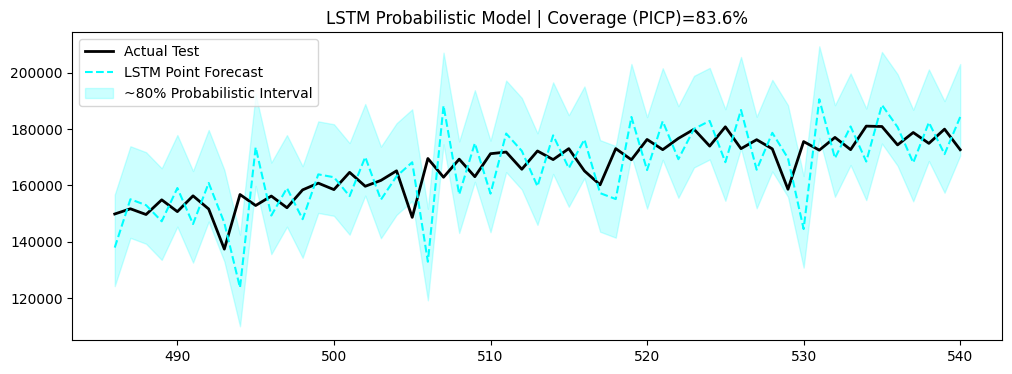

In [27]:
# Probabilistic Forecast (Conformal Bounds)
margin_q10 = np.percentile(best_lstm_residuals, 5)
margin_q90 = np.percentile(best_lstm_residuals, 95)

lstm_q10_orig = lstm_point_forecast + margin_q10
lstm_q90_orig = lstm_point_forecast + margin_q90

lstm_picp = float(((test_actuals >= lstm_q10_orig) & (test_actuals <= lstm_q90_orig)).mean())
lstm_mpiw = float((lstm_q90_orig - lstm_q10_orig).mean())

print(f'Rolling LSTM Probabilistic Forecast | PICP: {lstm_picp*100:.2f}% | Mean PI Width: {lstm_mpiw:,.0f} bbls')

# Plot LSTM Probabilistic
plt.figure(figsize=(12,4))
plt.plot(range(test_start, test_end), test_actuals, label='Actual Test', color='black', linewidth=2)
plt.plot(range(test_start, test_end), lstm_point_forecast, label='LSTM Point Forecast', color='cyan', linestyle='--')
plt.fill_between(range(test_start, test_end), lstm_q10_orig, lstm_q90_orig, color='cyan', alpha=0.2, label='~80% Probabilistic Interval')
plt.title(f'LSTM Probabilistic Model | Coverage (PICP)={lstm_picp*100:.1f}%')
plt.legend(); plt.show()

## 9a. RNN Model (Point Forecast)

RNN Selected via Val Set | timesteps=11 | Val MAPE: 3.23%
Rolling RNN Test Set MAPE: 2.64%


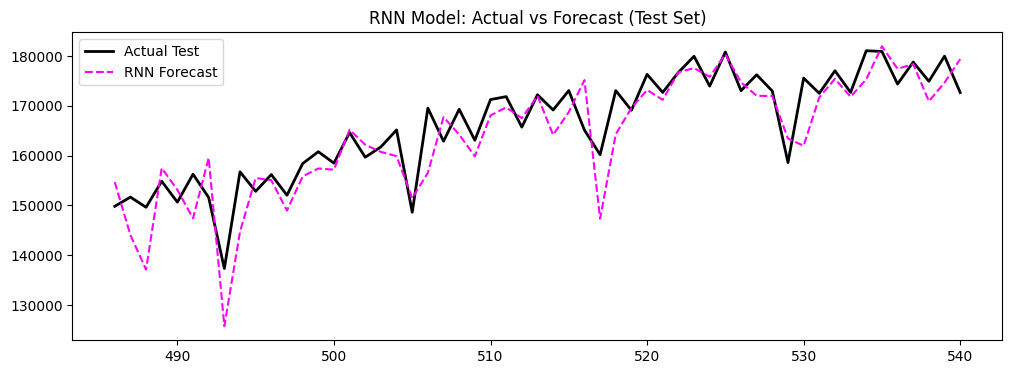

In [30]:
best_RNN = []
for ts in range(10, 16):
    x_tr, y_tr = create_sequences(train_scaled, ts)
    x_va, y_va = create_sequences(val_scaled, ts)

    def build_rnn(hp):
        m = Sequential()
        m.add(SimpleRNN(hp.Int('units', 16, 64, 16), activation='relu', input_shape=(ts, 1)))
        m.add(Dense(1))
        m.compile(optimizer='adam', loss='mse')
        return m

    tuner = kt.RandomSearch(build_rnn, 'val_loss', 3, directory='RNN_Tune', project_name=f'RNN_2_{ts}', overwrite=True)
    tuner.search(x_tr, y_tr, epochs=10, validation_data=(x_va, y_va), verbose=0)
    best_RNN.append((ts, tuner.get_best_models()[0]))

min_rnn_val_mape, rnn_model, rnn_ts = 1e9, None, None

for ts, model in best_RNN:
    x_tr, y_tr = create_sequences(train_scaled, ts)
    x_va, y_va = create_sequences(val_scaled, ts)
    model.fit(x_tr, y_tr, epochs=100, validation_data=(x_va, y_va), callbacks=[es], verbose=0)

    inputs_va = np.concatenate((train_scaled[-ts:], val_scaled))
    x_va_roll, _ = create_sequences(inputs_va, ts)

    # Predict Scaled Diff, INVERSE TRANSFORM, then reconstruct original
    pred_va_scaled = model.predict(x_va_roll, verbose=0)
    pred_va_sec_diff = scaler.inverse_transform(pred_va_scaled).flatten()
    pred_va_orig = pred_va_sec_diff + val_first_diff_prev + val_actuals_prev

    mape_va = mean_absolute_percentage_error(val_actuals, pred_va_orig)
    if mape_va < min_rnn_val_mape:
        min_rnn_val_mape = mape_va; rnn_model = model; rnn_ts = ts

print(f'RNN Selected via Val Set | timesteps={rnn_ts} | Val MAPE: {min_rnn_val_mape*100:.2f}%')

# Test Evaluation
inputs_r = np.concatenate((train_val_scaled[-rnn_ts:], test_scaled))
x_te_r, _ = create_sequences(inputs_r, rnn_ts)
rnn_pred_scaled = rnn_model.predict(x_te_r, verbose=0)
rnn_pred_sec_diff = scaler.inverse_transform(rnn_pred_scaled).flatten()
rnn_pred_orig = rnn_pred_sec_diff + test_first_diff_prev + test_actuals_prev

min_rnn_test = mean_absolute_percentage_error(test_actuals, rnn_pred_orig)
print(f'Rolling RNN Test Set MAPE: {min_rnn_test*100:.2f}%')

# Plot RNN
plt.figure(figsize=(12,4))
plt.plot(range(test_start, test_end), test_actuals, label='Actual Test', color='black', linewidth=2)
plt.plot(range(test_start, test_end), rnn_pred_orig, label='RNN Forecast', color='magenta', linestyle='--')
plt.title('RNN Model: Actual vs Forecast (Test Set)')
plt.legend(); plt.show()

## 9b. RNN Probabilistic Model (Conformal Calibration)

Rolling RNN Probabilistic Forecast | PICP: 81.82% | Mean PI Width: 26,421 bbls


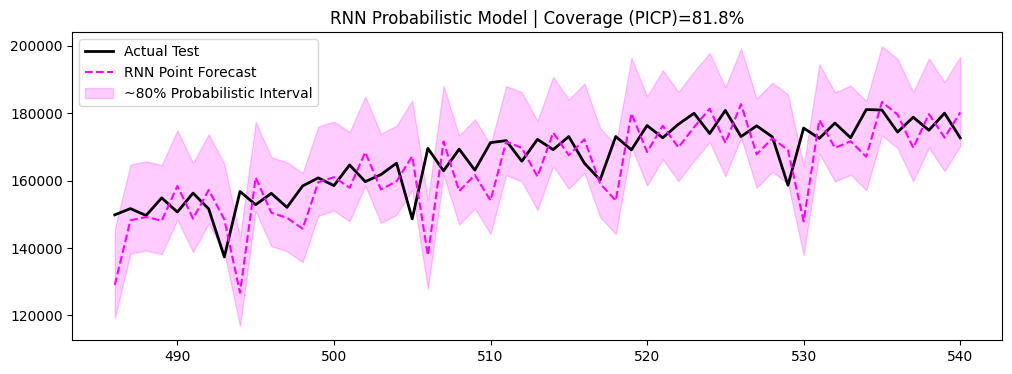

In [31]:
# Probabilistic Forecast (Conformal Bounds)
margin_q10 = np.percentile(best_rnn_residuals, 5)
margin_q90 = np.percentile(best_rnn_residuals, 95)

rnn_q10_orig = rnn_point_forecast + margin_q10
rnn_q90_orig = rnn_point_forecast + margin_q90

rnn_picp = float(((test_actuals >= rnn_q10_orig) & (test_actuals <= rnn_q90_orig)).mean())
rnn_mpiw = float((rnn_q90_orig - rnn_q10_orig).mean())

print(f'Rolling RNN Probabilistic Forecast | PICP: {rnn_picp*100:.2f}% | Mean PI Width: {rnn_mpiw:,.0f} bbls')

# Plot RNN Probabilistic
plt.figure(figsize=(12,4))
plt.plot(range(test_start, test_end), test_actuals, label='Actual Test', color='black', linewidth=2)
plt.plot(range(test_start, test_end), rnn_point_forecast, label='RNN Point Forecast', color='magenta', linestyle='--')
plt.fill_between(range(test_start, test_end), rnn_q10_orig, rnn_q90_orig, color='magenta', alpha=0.2, label='~80% Probabilistic Interval')
plt.title(f'RNN Probabilistic Model | Coverage (PICP)={rnn_picp*100:.1f}%')
plt.legend(); plt.show()

## 10. Statistical Quantile Regression (Statsmodels) Base Functions

In [32]:
import statsmodels.api as sm

quantile_levels = [0.10, 0.50, 0.90]
quantile_lag_candidates = [3, 6, 12]
vol_window_size = 6 # 6-month volatility feature

# Extract pure log SECOND differences
train_log_sec_diff = train['Log_Second_Diff'].dropna().reset_index(drop=True)
val_log_sec_diff = val['Log_Second_Diff'].reset_index(drop=True)
test_log_sec_diff = test['Log_Second_Diff'].reset_index(drop=True)

# Maintain continuous indices
val_log_sec_diff.index += len(train_log_sec_diff)
test_log_sec_diff.index += len(train_log_sec_diff) + len(val_log_sec_diff)
train_val_log_sec_diff = pd.concat([train_log_sec_diff, val_log_sec_diff])

def build_quantile_design_univ_vol(series, lag_count, vol_window):
    frame = pd.DataFrame({"y": series.astype(float)})
    for lag in range(1, lag_count + 1):
        frame[f"lag_{lag}"] = series.shift(lag)
    frame["rolling_std"] = series.shift(1).rolling(window=vol_window).std()
    frame = frame.dropna()
    X = sm.add_constant(frame.drop(columns=["y"]), has_constant="add")
    return X, frame["y"]

def fit_quantile_models_univ_vol(train_series, lag_count, quantiles, vol_window):
    X_train, y_train = build_quantile_design_univ_vol(train_series, lag_count, vol_window)
    models = {q: sm.QuantReg(y_train, X_train).fit(q=q, max_iter=10000) for q in quantiles}
    return models, X_train.columns

def predict_quantiles_with_models_univ_vol(models, feature_columns, history_series, target_series, lag_count, vol_window):
    history = history_series.astype(float).copy()
    preds = {q: [] for q in models.keys()}

    for idx, actual_val in target_series.items():
        row = {"const": 1.0}
        for lag in range(1, lag_count + 1):
            row[f"lag_{lag}"] = float(history.iloc[-lag])
        row["rolling_std"] = float(history.iloc[-vol_window:].std())

        X_next = pd.DataFrame([row], index=[idx]).reindex(columns=feature_columns, fill_value=0.0)
        for q, model in models.items():
            preds[q].append(float(model.predict(X_next).iloc[0]))
        history = pd.concat([history, pd.Series([float(actual_val)], index=[idx])])

    return pd.DataFrame(preds, index=target_series.index)
print("QuantReg functions loaded.")

QuantReg functions loaded.


## 11. Tune Quantile Regression Lag on Validation Set

In [33]:
print("Tuning Quantile Lags on Validation Set...")
best_lag, min_val_pinball = 3, 1e9

for lag in quantile_lag_candidates:
    q_models, f_cols = fit_quantile_models_univ_vol(train_log_sec_diff, lag, quantile_levels, vol_window_size)
    preds_val = predict_quantiles_with_models_univ_vol(q_models, f_cols, train_log_sec_diff, val_log_sec_diff, lag, vol_window_size)

    pb_loss = 0
    for q in quantile_levels:
        err = val_log_sec_diff.values - preds_val[q].values
        pb_loss += np.mean(np.maximum(q * err, (q - 1.0) * err))

    if pb_loss < min_val_pinball:
        min_val_pinball = pb_loss; best_lag = lag

print(f"Selected Best Lag Depth: {best_lag}")

Tuning Quantile Lags on Validation Set...
Selected Best Lag Depth: 12


## 12. Fit Final Regime-Aware Model & Generate Adaptive Conformal Forecast

In [34]:
# Fit Final Model on Modern Regime (last 120 months of Train+Val)
modern_window = 120
modern_train_log_sec_diff = train_val_log_sec_diff.iloc[-modern_window:]

q_models_final, f_cols_final = fit_quantile_models_univ_vol(
    modern_train_log_sec_diff, best_lag, quantile_levels, vol_window_size)

# Predict Base Quantiles on Test Set (This predicts Log Second Difference)
q_preds_test_sec_diff = predict_quantiles_with_models_univ_vol(
    q_models_final, f_cols_final, modern_train_log_sec_diff, test_log_sec_diff, best_lag, vol_window_size)

print("Applying Adaptive Walk-Forward Calibration...")

# Calculate starting residuals from the training regime
train_q50_preds = []
for idx in range(vol_window_size, len(modern_train_log_sec_diff)):
    row = {"const": 1.0}
    for lag in range(1, best_lag + 1):
        row[f"lag_{lag}"] = float(modern_train_log_sec_diff.iloc[idx - lag])
    row["rolling_std"] = float(modern_train_log_sec_diff.iloc[idx - vol_window_size : idx].std())
    X_next = pd.DataFrame([row]).reindex(columns=f_cols_final, fill_value=0.0)
    train_q50_preds.append(float(q_models_final[0.50].predict(X_next).iloc[0]))

residuals = list(modern_train_log_sec_diff.iloc[vol_window_size:].values - np.array(train_q50_preds))

# Walk-forward Calibration over Test Set
adaptive_q10_orig, adaptive_q90_orig, adaptive_q50_orig = [], [], []
test_q50_sec_diff = q_preds_test_sec_diff[0.50].values

# Need historical pieces for Inverse Log Second Diff Transform
safe_log_first_diff_prev = df['Log_First_Diff'].shift(1).iloc[val_idx:].values
safe_log_actuals_prev = np.log(df['Monthly oil production'].shift(1).iloc[val_idx:].values)


for i in range(len(test_q50_sec_diff)):
    # Adaptive Memory: only look at last 60 errors
    recent_residuals = residuals[-60:]

    emp_lower = np.percentile(recent_residuals, 10)
    emp_upper = np.percentile(recent_residuals, 90)

    q10_sec_diff = test_q50_sec_diff[i] + emp_lower
    q90_sec_diff = test_q50_sec_diff[i] + emp_upper
    q50_sec_diff = test_q50_sec_diff[i]

    # CRITICAL: Inverse Transform Log Second Difference -> Log Production -> Original Scale
    # Formula: log_orig = log_second_diff + log_first_diff_prev + log_actuals_prev
    log_first_prev = safe_log_first_diff_prev[i]
    log_act_prev = safe_log_actuals_prev[i]

    adaptive_q10_orig.append(np.exp(q10_sec_diff + log_first_prev + log_act_prev))
    adaptive_q50_orig.append(np.exp(q50_sec_diff + log_first_prev + log_act_prev))
    adaptive_q90_orig.append(np.exp(q90_sec_diff + log_first_prev + log_act_prev))

    # Append truth to sliding window
    true_error = test_log_sec_diff.iloc[i] - test_q50_sec_diff[i]
    residuals.append(true_error)

Applying Adaptive Walk-Forward Calibration...


FINAL ADAPTIVE MODEL | RMSE: 6,110 | MAE: 4,061 | MAPE: 2.54% | R2: 0.6497 | PICP: 78.18%


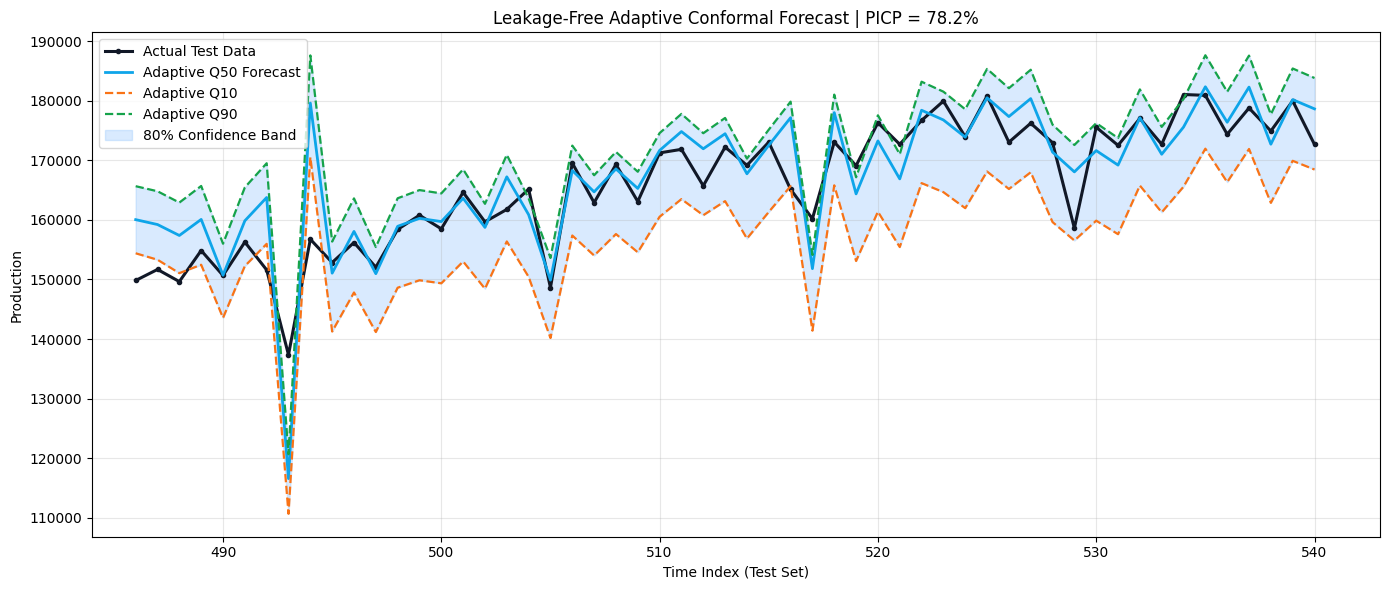

In [35]:
x_vals = list(range(test_start, test_end))
q_test_orig = pd.DataFrame(index=x_vals)
q_test_orig["q50"] = adaptive_q50_orig
q_test_orig["q10"] = adaptive_q10_orig
q_test_orig["q90"] = adaptive_q90_orig

# Extract metrics using helper function
rmse_quant, mae_quant, mape_quant, r2_quant = get_error_metrics(test_actuals, q_test_orig["q50"])
coverage = float(((test_actuals >= q_test_orig["q10"]) & (test_actuals <= q_test_orig["q90"])).mean())
width = float((q_test_orig["q90"] - q_test_orig["q10"]).mean())

print(f"FINAL ADAPTIVE MODEL | RMSE: {rmse_quant:,.0f} | MAE: {mae_quant:,.0f} | MAPE: {mape_quant*100:.2f}% | R2: {r2_quant:.4f} | PICP: {coverage*100:.2f}%")

plt.figure(figsize=(14, 6))
plt.plot(x_vals, test_actuals, color="#111827", linewidth=2.2, label="Actual Test Data", marker='.')
plt.plot(x_vals, q_test_orig["q50"], color="#0ea5e9", linewidth=2.0, label="Adaptive Q50 Forecast")
plt.plot(x_vals, q_test_orig["q10"], color="#f97316", linewidth=1.6, linestyle="--", label="Adaptive Q10")
plt.plot(x_vals, q_test_orig["q90"], color="#16a34a", linewidth=1.6, linestyle="--", label="Adaptive Q90")
plt.fill_between(x_vals, q_test_orig["q10"], q_test_orig["q90"], color="#93c5fd", alpha=0.35, label="80% Confidence Band")

plt.title(f"Leakage-Free Adaptive Conformal Forecast | PICP = {coverage*100:.1f}%")
plt.xlabel("Time Index (Test Set)")
plt.ylabel("Production")
plt.xlim(test_start - 2, test_end + 2)
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Comprehensive Final Comparison Dashboard

=== Final Test Set Evaluation Metrics ===


,Model,Train/Val AIC,Test RMSE,Test MAE,Test MAPE (%),Test R²,PICP (%) [80% Target],Mean PI Width (bbls)
0,AR,7115.051900,7498.970000,5869.404800,3.589900,0.472400,N/A,N/A
1,MA,7164.327200,6626.793000,4932.635700,3.015900,0.588000,N/A,N/A
2,ARIMA,7112.556800,6761.350200,5284.999700,3.238800,0.571100,N/A,N/A
3,SARIMA,6245.094900,4057.643800,2733.750400,1.680900,0.845500,N/A,N/A
4,GRU,N/A,5288.720000,4203.915400,2.546200,0.737600,87.272700,17264.676700
5,LSTM,N/A,5627.590200,4280.728900,2.584600,0.702900,83.636400,32539.024500
6,RNN,N/A,5676.656200,4289.756600,2.640500,0.697700,81.818200,26421.065900
7,QuantReg,N/A,6110.389400,4061.467600,2.537500,0.649700,78.181800,14665.767700


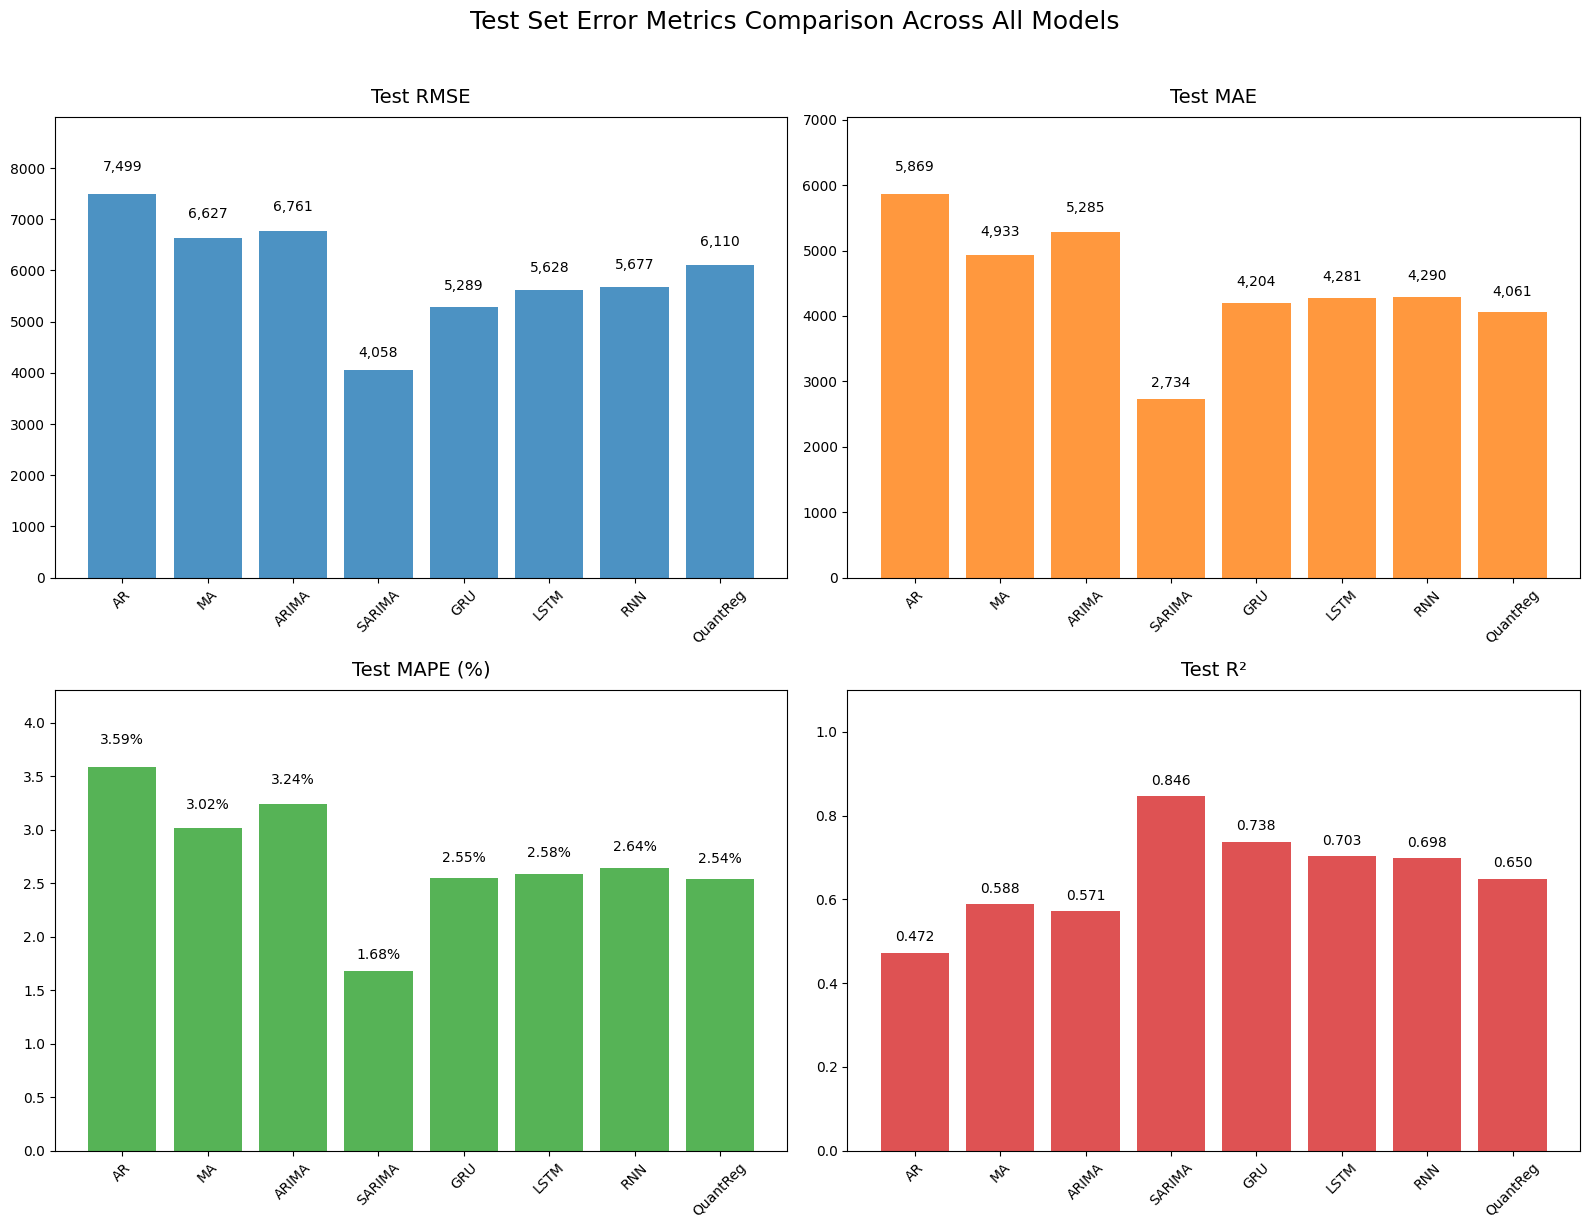

In [40]:
import matplotlib.pyplot as plt
from IPython.display import display
import pandas as pd
import numpy as np

# 1. Calculate point error metrics for DL models
# (Assuming your point forecasts are named gru_q50_orig, etc. If you used gru_pred_orig, change them here)
rmse_gru, mae_gru, mape_gru, r2_gru = get_error_metrics(test_actuals, gru_pred_orig)
rmse_lstm, mae_lstm, mape_lstm, r2_lstm = get_error_metrics(test_actuals, lstm_pred_orig)
rmse_rnn, mae_rnn, mape_rnn, r2_rnn = get_error_metrics(test_actuals, rnn_pred_orig)

# 2. Calculate PICP and Mean PI Width for DL Models
gru_picp = float(((test_actuals >= gru_q10_orig) & (test_actuals <= gru_q90_orig)).mean())
gru_mpiw = float((gru_q90_orig - gru_q10_orig).mean())

lstm_picp = float(((test_actuals >= lstm_q10_orig) & (test_actuals <= lstm_q90_orig)).mean())
lstm_mpiw = float((lstm_q90_orig - lstm_q10_orig).mean())

rnn_picp = float(((test_actuals >= rnn_q10_orig) & (test_actuals <= rnn_q90_orig)).mean())
rnn_mpiw = float((rnn_q90_orig - rnn_q10_orig).mean())

# 3. Compile all results into a single master table
results_df = pd.DataFrame({
    "Model": ['AR', 'MA', 'ARIMA', 'SARIMA', 'GRU', 'LSTM', 'RNN', 'QuantReg'],
    "Train/Val AIC": [ar_aic, ma_aic, arima_aic, sarima_aic, np.nan, np.nan, np.nan, np.nan],
    "Test RMSE": [rmse_ar, rmse_ma, rmse_arima, rmse_sarima, rmse_gru, rmse_lstm, rmse_rnn, rmse_quant],
    "Test MAE": [mae_ar, mae_ma, mae_arima, mae_sarima, mae_gru, mae_lstm, mae_rnn, mae_quant],
    "Test MAPE (%)": [mape_ar*100, mape_ma*100, mape_arima*100, mape_sarima*100, mape_gru*100, mape_lstm*100, mape_rnn*100, mape_quant*100],
    "Test R²": [r2_ar, r2_ma, r2_arima, r2_sarima, r2_gru, r2_lstm, r2_rnn, r2_quant],
    "PICP (%) [80% Target]": [np.nan, np.nan, np.nan, np.nan, gru_picp*100, lstm_picp*100, rnn_picp*100, coverage*100],
    "Mean PI Width (bbls)": [np.nan, np.nan, np.nan, np.nan, gru_mpiw, lstm_mpiw, rnn_mpiw, width]
})

print("=== Final Test Set Evaluation Metrics ===")
display(results_df.round(4).style.format(na_rep="N/A"))
print("\n")

# ---- 4. PLOTTING THE 4 ERROR COMPARISONS ----
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Test Set Error Metrics Comparison Across All Models', fontsize=18, y=1.02)

metrics = ['Test RMSE', 'Test MAE', 'Test MAPE (%)', 'Test R²']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, ax in enumerate(axes.flatten()):
    metric = metrics[i]
    bars = ax.bar(results_df['Model'], results_df[metric], color=colors[i], alpha=0.8)
    ax.set_title(metric, fontsize=14, pad=10)
    ax.tick_params(axis='x', rotation=45)

    # Add numerical labels on top of the bars
    for bar in bars:
        value = bar.get_height()
        # Handle formatting based on metric scale
        if metric == 'Test R²':
            label = f'{value:.3f}'
            offset = 0.02 if value > 0 else -0.05
        elif metric == 'Test MAPE (%)':
            label = f'{value:.2f}%'
            offset = value * 0.05
        else:
            label = f'{value:,.0f}'
            offset = value * 0.05

        ax.text(bar.get_x() + bar.get_width()/2, value + offset, label, ha='center', va='bottom', fontsize=10)

    # Adjust Y-limits to make room for text
    if metric == 'Test R²':
        ax.set_ylim(min(0, results_df[metric].min() - 0.2), 1.1)
    else:
        ax.set_ylim(0, results_df[metric].max() * 1.2)

plt.tight_layout()
plt.show()